In [8]:
import pandas as pd

df = pd.read_csv("mall_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


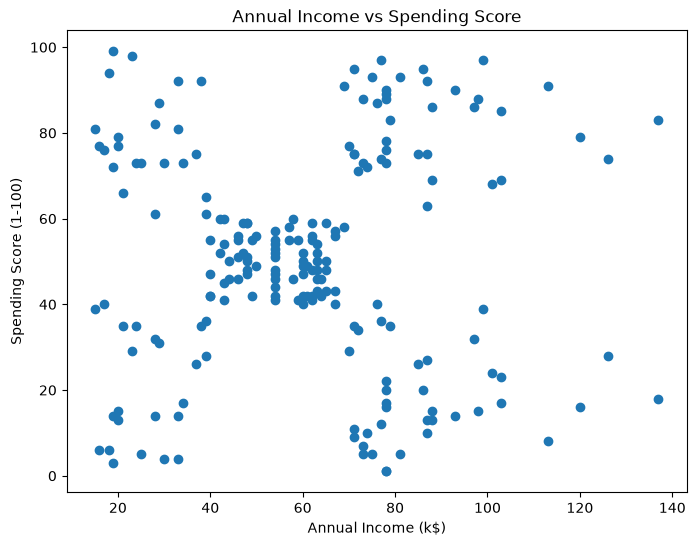

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()

In [10]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

C:\Users\SAYED TOUHEED SHAH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\SAYED TOUHEED SHAH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\SAYED TOUHEED SHAH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\SAYED TOUHEED SHAH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarn

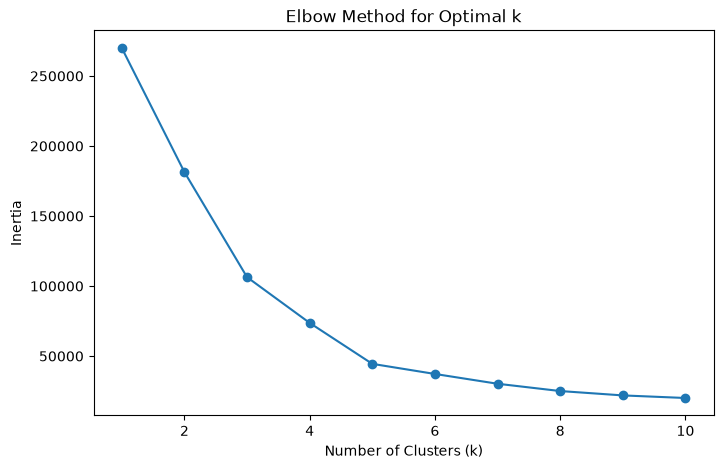

In [11]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)
df.head()

C:\Users\SAYED TOUHEED SHAH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


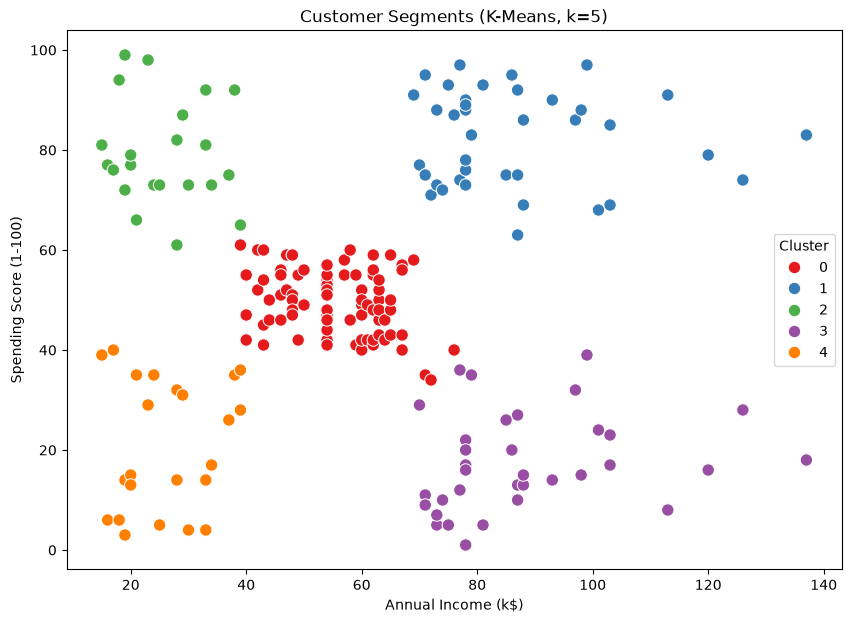

In [13]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                 hue='Cluster', palette='Set1', s=80)
plt.title('Customer Segments (K-Means, k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

In [14]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Key Insights

Using K-Means clustering (k=5, chosen via the Elbow Method), customers 
segment into 5 distinct groups based on Annual Income and Spending Score:

| Cluster | Avg Income | Avg Spending | Segment |
|---------|-----------|---------------|---------|
| 0 | $55.3k | 49.5 | Average customers (largest group) |
| 1 | $86.5k | 82.1 | High income, high spending — best customers |
| 2 | $25.7k | 79.4 | Low income, high spending — impulsive spenders |
| 3 | $88.2k | 17.1 | High income, low spending — untapped potential |
| 4 | $26.3k | 20.9 | Low income, low spending — budget-conscious |

**Business recommendations:**
- Cluster 1 (best customers) should get loyalty/VIP programs to retain them
- Cluster 3 (high income, low spending) represents the biggest growth 
  opportunity — targeted campaigns could convert them into higher spenders
- Cluster 2 (impulsive, lower income) responds well to promotions/discounts
- Cluster 4 (budget-conscious) is price-sensitive — value-based marketing 
  would likely resonate more than premium positioning